In [1]:
import sys
sys.path.append('..')

### Importamos librerias y clases

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dirac_solver.geometry import Grid

from dirac_solver.initial_state import InitialState, ConstantSpinor, GaussianPacket, PlaneWave

from dirac_solver.core import DiracProblemBuilder, DiracSolver
from dirac_solver import _core

In [3]:
print("--- Configurando parámetros de simulación ---")
shape = (400,)
spacing = (0.1,)
grid = Grid(shape, spacing)

--- Configurando parámetros de simulación ---


### Se define spinor constante con momento x

In [4]:
constant_spinor = ConstantSpinor(momentum=[5,0,0])

### Definimos potencial particula libre y bordes absorbentes

In [5]:
potential = _core.FreeParticle()
boundary = _core.AbsorbingBoundary(strength=0.1)

In [6]:
time_step = 0.001
total_time = 2.0

## Simulación con GaussianPacket

In [7]:
gauss_state = GaussianPacket(
    constant_spinor,
    center=[-10,0,0],
    spatial_width=2.0
)

gauss_problem = DiracProblemBuilder() \
    .set_grid(grid) \
    .set_initial_state(gauss_state) \
    .set_potential(potential) \
    .set_boundary_condition(boundary) \
    .set_time_parameters(time_step=time_step, total_time=total_time) \
    .build()

gauss_solver = DiracSolver(gauss_problem)
gauss_solver.run_simulation()

DiracSolver inicializado con el motor C++ 'FDTDLeapfrogIntegrator'.
Ejecutando simulación por 2000 pasos...
  Paso 10/2000 completado.
  Paso 20/2000 completado.
  Paso 30/2000 completado.
  Paso 40/2000 completado.
  Paso 50/2000 completado.
  Paso 60/2000 completado.
  Paso 70/2000 completado.
  Paso 80/2000 completado.
  Paso 90/2000 completado.
  Paso 100/2000 completado.
  Paso 110/2000 completado.
  Paso 120/2000 completado.
  Paso 130/2000 completado.
  Paso 140/2000 completado.
  Paso 150/2000 completado.
  Paso 160/2000 completado.
  Paso 170/2000 completado.
  Paso 180/2000 completado.
  Paso 190/2000 completado.
  Paso 200/2000 completado.
  Paso 210/2000 completado.
  Paso 220/2000 completado.
  Paso 230/2000 completado.
  Paso 240/2000 completado.
  Paso 250/2000 completado.
  Paso 260/2000 completado.
  Paso 270/2000 completado.
  Paso 280/2000 completado.
  Paso 290/2000 completado.
  Paso 300/2000 completado.
  Paso 310/2000 completado.
  Paso 320/2000 completado.
  Pas

In [8]:
psi_gauss = gauss_solver.get_psi()
rho_gauss = np.sum(psi_gauss.conj() * psi_gauss, axis=1).real

## Simulación con PlaneWave

In [9]:
plane_wave_state = PlaneWave(constant_spinor)

plane_wave_problem = DiracProblemBuilder() \
    .set_grid(grid) \
    .set_initial_state(plane_wave_state) \
    .set_potential(potential) \
    .set_boundary_condition(boundary) \
    .set_time_parameters(time_step=time_step, total_time=total_time) \
    .build()

plane_wave_solver = DiracSolver(plane_wave_problem)
plane_wave_solver.run_simulation()

DiracSolver inicializado con el motor C++ 'FDTDLeapfrogIntegrator'.
Ejecutando simulación por 2000 pasos...
  Paso 10/2000 completado.
  Paso 20/2000 completado.
  Paso 30/2000 completado.
  Paso 40/2000 completado.
  Paso 50/2000 completado.
  Paso 60/2000 completado.
  Paso 70/2000 completado.
  Paso 80/2000 completado.
  Paso 90/2000 completado.
  Paso 100/2000 completado.
  Paso 110/2000 completado.
  Paso 120/2000 completado.
  Paso 130/2000 completado.
  Paso 140/2000 completado.
  Paso 150/2000 completado.
  Paso 160/2000 completado.
  Paso 170/2000 completado.
  Paso 180/2000 completado.
  Paso 190/2000 completado.
  Paso 200/2000 completado.
  Paso 210/2000 completado.
  Paso 220/2000 completado.
  Paso 230/2000 completado.
  Paso 240/2000 completado.
  Paso 250/2000 completado.
  Paso 260/2000 completado.
  Paso 270/2000 completado.
  Paso 280/2000 completado.
  Paso 290/2000 completado.
  Paso 300/2000 completado.
  Paso 310/2000 completado.
  Paso 320/2000 completado.
  Pas

In [10]:
psi_plane = plane_wave_solver.get_psi()
rho_plane = np.sum(psi_plane.conj() * psi_plane, axis=1).real

## Graficamos los resultados comparativos

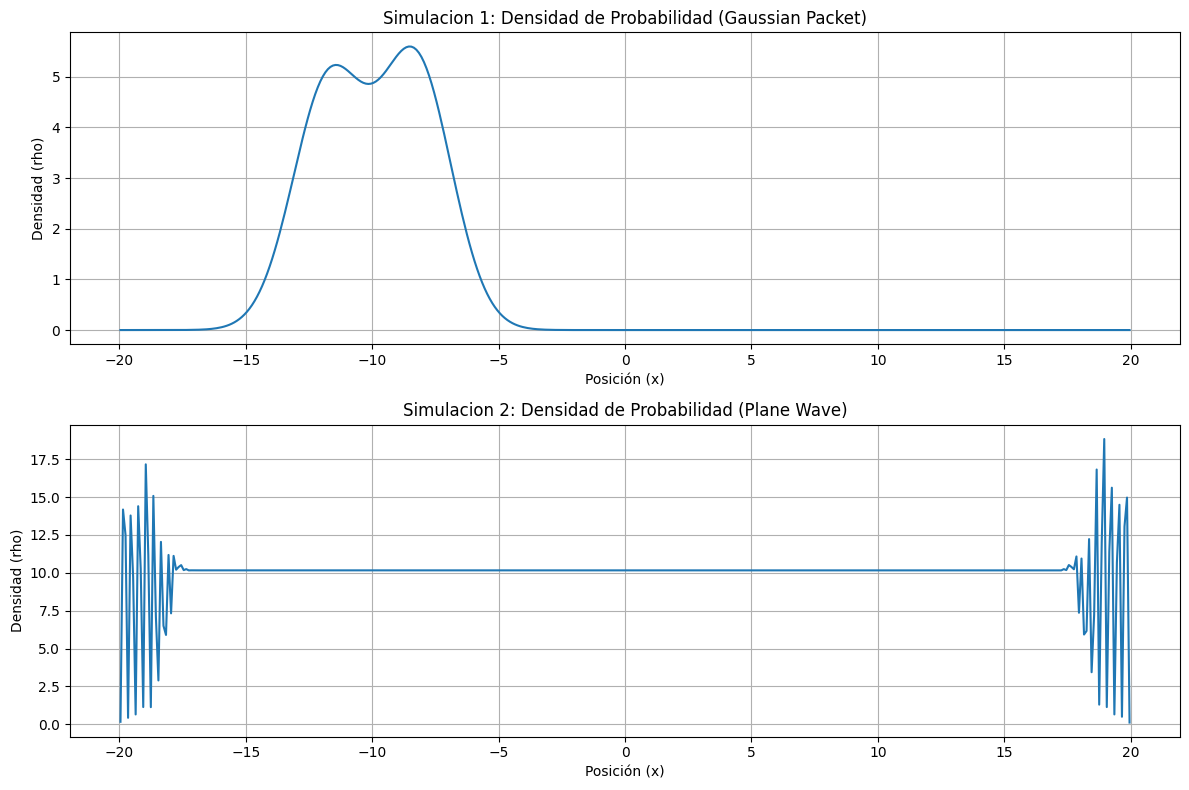

In [15]:
x_coords = grid.coords[:,0]

plt.figure(figsize=(12,8))

# Grafico del Paquete Gaussiano

plt.subplot(2,1,1)
plt.plot(x_coords,rho_gauss)
plt.title("Simulacion 1: Densidad de Probabilidad (Gaussian Packet)")
plt.xlabel("Posición (x)")
plt.ylabel("Densidad (rho)")
plt.grid(True)

# Grafico de la onda plana

plt.subplot(2,1,2)
plt.plot(x_coords,rho_plane)
plt.title("Simulacion 2: Densidad de Probabilidad (Plane Wave)")
plt.xlabel("Posición (x)")
plt.ylabel("Densidad (rho)")
plt.grid(True)

plt.tight_layout()
plt.show()